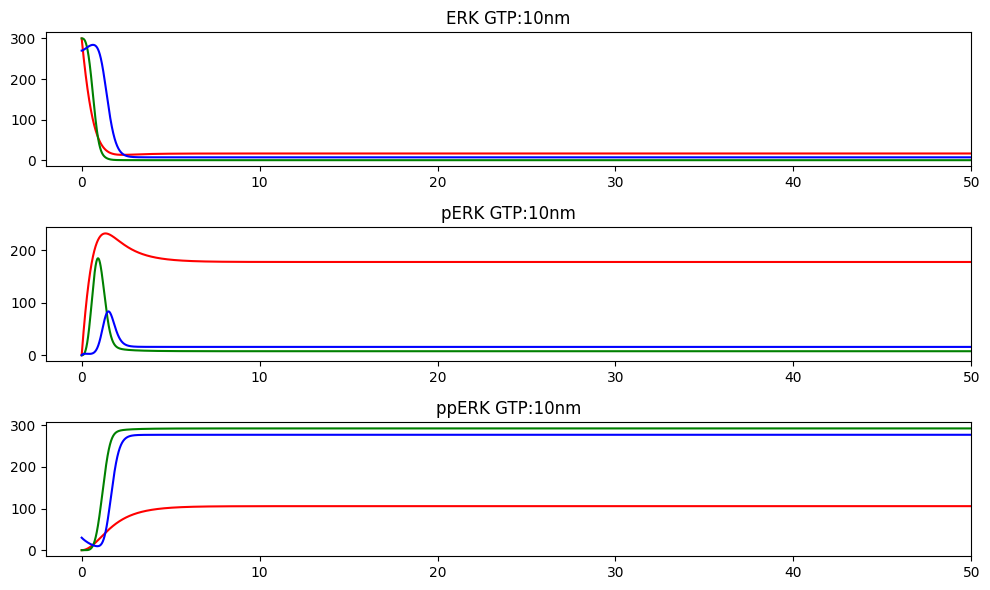

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#get_ipython().run_line_magic('matplotlib', 'notebook')
from scipy.integrate import odeint
from matplotlib.animation import FuncAnimation
%matplotlib inline
#Parameter values
nequ=9
k1=1.0
km1=100.0
km2=200.0
k2=0.25
k3=2.5
km3=50.0
km4=100.0
k4=3.75
k5=2.5
km5=250.0
km6=250.0
k6=0.5
k7=3.0
km7=250.0
km8=80.0
k8=3.75
k9=0.125
km9=250.0
km10=250.0
k10=0.125
k11=3.75
km11=120.0
km12=20.0
k12=5.0
km13=300.0 


#------------------------------------------------------------------#

# SUSTAINED SIGNALLING 
F   = 1.0 # no feedback
kf  = 1.0 # irrelevant if F=1.0
GTP = 1.0
k1  = 1.0  # nM / s
k7  = 3.0  # nM / s
k11 = 3.75 # nM / s

# TRANSIENT w ADAPTATION
F   = 0.01
kf  = 1.0   # nM
k7  = 0.175 # nM / s
k1  = 1.0   # nM / s
k11 = 3.75  # nM / s
GTP_INTITAL = 10 # nM


# OSCILLATORY


# BISTABLE
""" F=5.0
kf=100.0 #nM
k1=0.025 #nM/s
k11=0.025 #nM/s
k7=3.0 #nM/s """


#initial conditions
y0 =  [0] * nequ
y0[0] = y0[3] = y0[6] = 300.0 # RAF - MEK - ERK
y0[8] = 20.0                  # ppERK
y0[6] = 300.0 - y0[8]         # ERK

#------------------------------------------------------------------#
#Derivatives
def dy_dt(y,t):
    RAF, pRAF, ppRAF, MEK, pMEK, ppMEK, ERK, pERK, ppERK = y

    v1 = ( ( (k1*gtp*RAF)   / km1 ) / ( 1+(RAF/km1)+(pRAF/km2) ) ) * ( (1+(F*ppERK)/kf) /  (1+(ppERK)/kf))
    v2 = ( ( (k2*gtp*pRAF)  / km2 ) / ( 1+(RAF/km1)+(pRAF/km2) ) ) * ( (1+(F*ppERK)/kf) /  (1+(ppERK)/kf))
    v3 = ( (k3*ppRAF) / km3 )       / ( 1+(ppRAF/km3)+(pRAF/km4) )
    v4 = ( (k4*ppRAF) / km4 )       / ( 1+(ppRAF/km3)+(pRAF/km4) )

    v5 = ( (k5*ppRAF*MEK)  / km5 )  / ( 1+(MEK/km5)+(pMEK/km6) )
    v6 = ( (k6*ppRAF*pMEK) / km6 )  / ( 1+(MEK/km5)+(pMEK/km6) )
    v7 = ( (k7*ppMEK) / km7 )       / ( 1+(ppMEK/km7)+(pMEK/km8) )
    v8 = ( (k8*pMEK)  / km8 )       / ( 1+(ppMEK/km7)+(pMEK/km8) )

    v9  = ( (k9*ppMEK*ERK)   / km9 )   / ( 1+(ERK/km9)+(pERK/km10) )
    v10 = ( (k10*ppMEK*pERK) / km10 )  / ( 1+(ERK/km9)+(pERK/km10) )
    v11 = ( (k11*ppERK) / km11 )       / ( 1+(ppERK/km11)+(pERK/km12) )
    v12 = ( (k12*pERK)  / km12 )       / ( 1+(ppERK/km11)+(pERK/km12) )
    
    dy = []
    dy.append( v4 - v1 )           # RAF
    dy.append( v1 - v2 + v3 - v4 ) # pRAF
    dy.append( v2 - v3 )           # ppRAF

    dy.append( v8 - v5 )           # MEK
    dy.append( v5 - v6 + v7 - v8 ) # pMEK
    dy.append( v6 - v7 )           # ppMEK

    dy.append( v12 - v9 )             # ERK
    dy.append( v9 - v10 + v11 - v12 ) # pERK
    dy.append( v10 - v11 )            # ppERK
    return dy    

#Integration of ODEs
GTP = np.arange(10,11,1)
fig, ax = plt.subplots(3,1, figsize=(10,6))
lines = []
colors=['red', 'red', 'red', 'green', 'green', 'green', 'blue', 'blue', 'blue']
cols=["Raf", "pRaf","ppRaf","MEK","pMEK","ppMEK","ERK","pERK","ppERK"]

for gtp in GTP:
    #initial conditions
    y0 =  [0] * nequ
    y0[0] = y0[3] = y0[6] = 300.0
    y0[8] = 30.0
    y0[6] = 300.0 - y0[8]
    
    t_min = 50
    t = np.linspace(0, t_min * 60 + 1, 10000)
    sol = odeint(func=dy_dt, y0=y0, t=t)
    lines.append(sol)
    sol = pd.DataFrame(sol, columns=["Raf", "pRaf","ppRaf","MEK","pMEK","ppMEK","ERK","pERK","ppERK"])
    
    # HERE
    #lines.append(sol.values)

    sol.index = t
    sol.index = sol.index/60
    
    #fig, ax = plt.subplots(3,1, figsize=(10,6))
    colors=['red', 'red', 'red', 'green', 'green', 'green', 'blue', 'blue', 'blue']
    for i, col in enumerate(sol.columns):
        r = i // 3
        c = i % 3
        ax[c].plot(sol.index, sol[col], color=colors[i], label=col)
        ax[c].set_title(f'{col} GTP:{gtp}nm')
        #ax[c].legend()
        ax[c].set_xlim(-2,t_min)
plt.tight_layout()
plt.show()

In [2]:

NA = 6.022e23
V  = 1e-15
CONV = 1e-9 * NA * V
INV_CONV = 1.0 / CONV


def gillespie_mapk(y0, tmax):

    # --- concentrations → molecule counts ---
    state = np.round(np.array(y0) * CONV).astype(int)

    t = 0.0
    times = [t]
    traj_counts = [state.copy()]
    traj_conc   = [state * INV_CONV]

    while t < tmax:

        # unpack counts
        RAF_S, pRAF_S, ppRAF_S, MEK_S, pMEK_S, ppMEK_S, ERK_S, pERK_S, ppERK_S = state

        # convert to concentrations for rate laws
        RAF, pRAF, ppRAF, MEK, pMEK, ppMEK, ERK, pERK, ppERK = state * INV_CONV

        # --- propensities (convert to counts-based by multiplying by V*NA) ---
        v1 = ( ( (k1*gtp*RAF)   / km1 ) / (1+(RAF/km1)+(pRAF/km2)) ) * ( (1+(F*ppERK)/kf) / (1+(ppERK)/kf) )
        v2 = ( ( (k2*gtp*pRAF)  / km2 ) / (1+(RAF/km1)+(pRAF/km2)) ) * ( (1+(F*ppERK)/kf) / (1+(ppERK)/kf) )
        v3 = ( (k3*ppRAF) / km3 )       / (1+(ppRAF/km3)+(pRAF/km4))
        v4 = ( (k4*ppRAF) / km4 )       / (1+(ppRAF/km3)+(pRAF/km4))

        v5 = ( (k5*ppRAF*MEK)  / km5 )  / (1+(MEK/km5)+(pMEK/km6))
        v6 = ( (k6*ppRAF*pMEK) / km6 )  / (1+(MEK/km5)+(pMEK/km6))
        v7 = ( (k7*ppMEK) / km7 )       / (1+(ppMEK/km7)+(pMEK/km8))
        v8 = ( (k8*pMEK)  / km8 )       / (1+(ppMEK/km7)+(pMEK/km8))

        v9  = ( (k9*ppMEK*ERK)   / km9 )   / (1+(ERK/km9)+(pERK/km10))
        v10 = ( (k10*ppMEK*pERK) / km10 )  / (1+(ERK/km9)+(pERK/km10))
        v11 = ( (k11*ppERK) / km11 )       / (1+(ppERK/km11)+(pERK/km12))
        v12 = ( (k12*pERK)  / km12 )       / (1+(ppERK/km11)+(pERK/km12))

        # convert rates (nM/s) → molecule propensities
        a = np.array([v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,v11,v12]) * CONV
        a0 = a.sum()

        if a0 <= 0:
            break

        # time step
        tau = -np.log(np.random.rand()) / a0
        t += tau

        # Modifying it to have reactions per tau
        #REACTIONS_PER_TAU = np.random.randint(1,12)
        REACTIONS_PER_TAU = 1
        for _ in range(REACTIONS_PER_TAU):
            # reaction selection
            r2 = np.random.rand() * a0
            reaction = np.searchsorted(np.cumsum(a), r2)

            # --- state updates ---
            if reaction == 0 and RAF_S > 0:
                state[0] -= 1; state[1] += 1
            elif reaction == 1 and state[1] > 0:
                state[1] -= 1; state[2] += 1
            elif reaction == 2 and state[2] > 0:
                state[2] -= 1; state[1] += 1
            elif reaction == 3 and state[1] > 0:
                state[1] -= 1; state[0] += 1

            elif reaction == 4 and state[3] > 0:
                state[3] -= 1; state[4] += 1
            elif reaction == 5 and state[4] > 0:
                state[4] -= 1; state[5] += 1
            elif reaction == 6 and state[5] > 0:
                state[5] -= 1; state[4] += 1
            elif reaction == 7 and state[4] > 0:
                state[4] -= 1; state[3] += 1

            elif reaction == 8 and state[6] > 0:
                state[6] -= 1; state[7] += 1
            elif reaction == 9 and state[7] > 0:
                state[7] -= 1; state[8] += 1
            elif reaction == 10 and state[8] > 0:
                state[8] -= 1; state[7] += 1
            elif reaction == 11 and state[7] > 0:
                state[7] -= 1; state[6] += 1
            
        # store
        times.append(t)
        traj_counts.append(state.copy())
        traj_conc.append(state * INV_CONV)

    return np.array(times), np.array(traj_conc), np.array(traj_counts)

In [3]:
## DO GILLESPISE SIM ##
#initial conditions
#Convert to number from concentration
NA = 6.022e23
V = 1e-15

CONV = 1e-9 * NA * V      # nM → molecules
INV_CONV = 1.0 / CONV     # molecules → nM

minutes = 50
TMAX = 60 * minutes

def conc_to_counts(c_nM):
    return int(round(c_nM * CONV))

def counts_to_conc(x_counts):
    return x_counts * INV_CONV


# --- INITIAL CONDITIONS (ONLY concentrations) ---
c0 = np.zeros(9)
c0[0] = 300   # RAF (nM)
c0[3] = 300   # MEK
c0[6] = 300   # ERK
c0[8] = 20    # ppERK
c0[6] -= c0[8]

# --- convert once ---
x0 = np.array([conc_to_counts(c) for c in c0])

# --- run SSA ---
#t, traj = gillespie_mapk_conc(c0, 10000)
t, traj, traj_counts = gillespie_mapk(c0, TMAX)

# --- time axis for plotting ---
t_ = np.linspace(0, t[-1], len(t))


Text(0, 0.5, 'ppERK')

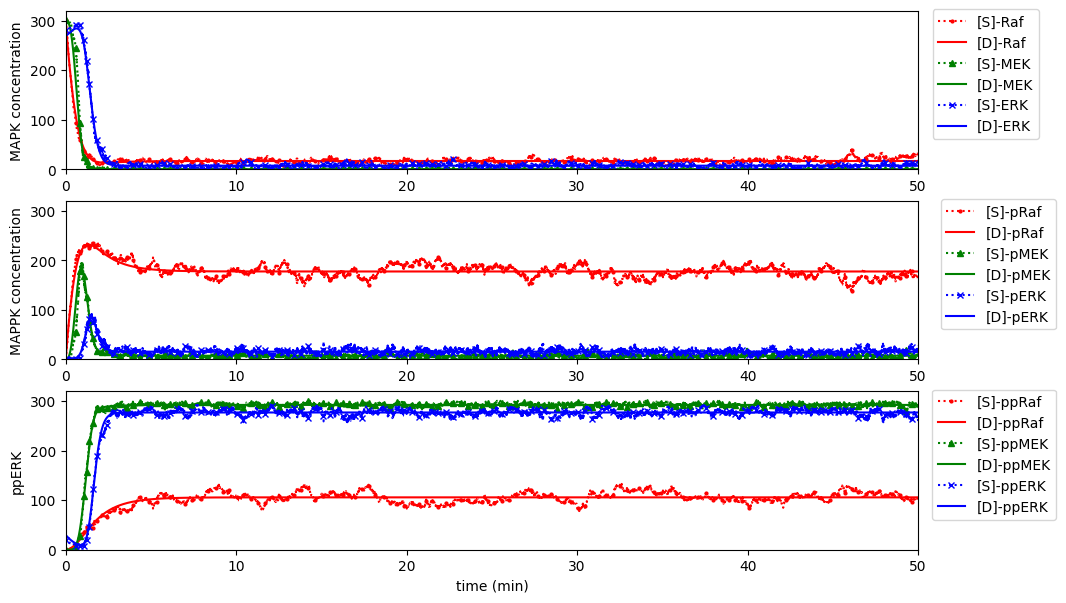

In [4]:
fig, ax = plt.subplots(3,1, figsize=(11,7))

for a in ax:
    a.set_xlim(0, t[-1]/60)
    a.set_ylim(0, 320)

colors = ['red','red','red','green','green','green','blue','blue','blue']
labels = ["Raf","pRaf","ppRaf","MEK","pMEK","ppMEK","ERK","pERK","ppERK"]
linestyles=['--','--','--',':',':',':','-','-','-']
markers=[".",".",".", "^","^","^", "x","x","x"]

for i in range(9):
    ax[i % 3].plot(t/60, traj[:,i], color=colors[i], marker=markers[i], markevery=200, markersize=4, linestyle=":", label="[S]-"+cols[i])
    ax[i % 3].plot(sol.index, sol[f"{labels[i]}"], color=colors[i], marker=None, markevery=20, markersize=4, linestyle='-', label="[D]-"+cols[i])

ax[0].set_ylabel("MAPK concentration")
ax[1].set_ylabel("MAPPK concentration")
ax[2].set_ylabel("MAPPPK concentration")
ax[2].set_xlabel("Time")
ax[0].legend(loc='right',bbox_to_anchor=(1.15, 0.6))
ax[1].legend(loc='right',bbox_to_anchor=(1.17, 0.6))
ax[2].legend(loc='right',bbox_to_anchor=(1.17, 0.6))
#plt.plot(t/60, traj[:,8])
plt.xlabel("time (min)")
plt.ylabel("ppERK")


####### ISSUE IS WITH POWER OF 10, CHECK init cond. Curves should match. 